In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [5]:
base_path = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"

In [6]:
label_map = {
    "COVID": 0,
    "Normal": 1,
    "Lung_Opacity": 2,
    "Viral Pneumonia": 3
}

In [7]:
image_paths = []
labels = []

for class_name in label_map:

    folder = os.path.join(
        base_path,
        class_name,
        "images"
    )

    for image_name in os.listdir(folder):

        image_paths.append(
            os.path.join(folder, image_name)
        )

        labels.append(
            label_map[class_name]
        )

In [8]:
print("Total Images:", len(image_paths))
print("Total Labels:", len(labels))

Total Images: 21165
Total Labels: 21165


In [9]:
class ChestXrayDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels
    ):

        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):

        return len(
            self.image_paths
        )

    def __getitem__(
        self,
        idx
    ):

        image = cv2.imread(
            self.image_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            (224,224)
        )

        image = image / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        image = image.unsqueeze(0)

        label = self.labels[idx]

        return image, label

In [10]:
dataset = ChestXrayDataset(
    image_paths,
    labels
)

In [11]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([1, 224, 224])
0


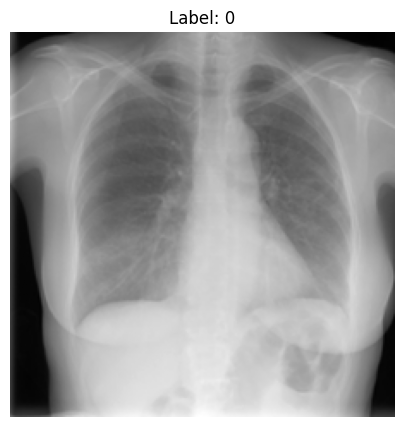

In [12]:
plt.figure(figsize=(5,5))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Label: {label}"
)

plt.axis("off")

plt.show()

In [13]:
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [14]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 224, 224])
torch.Size([32])


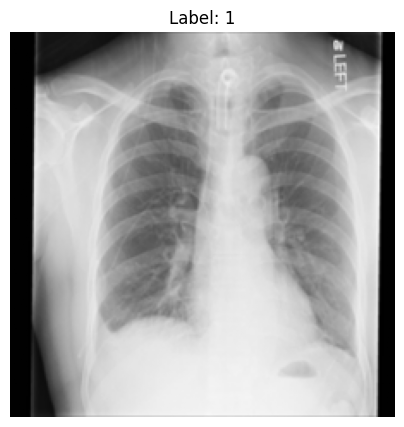

In [15]:
plt.figure(figsize=(5,5))

plt.imshow(
    images[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Label: {labels[0]}"
)

plt.axis("off")

plt.show()

In [16]:
print(
    len(train_loader)
)

662


In [17]:
image, label = dataset[0]

In [18]:
images, labels = next(
    iter(train_loader)
)

In [19]:
torch.Size([32,1,224,224])

torch.Size([32])

torch.Size([32])